In [ ]:
!pip install numpy==1.24.4 scikit-learn==1.3.0 scikit-learn-extra==0.3.0

INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 22.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.0
    Uninstalling scipy-1.16.0:
      Successfully uninstalled scipy-1.16.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.

In [ ]:
from google.colab import drive
import sys
drive.mount('/content/drive/', force_remount=True)
sys.path.append('/content/drive/MyDrive/ERI')
#Auxiliar1: ORB + CLARA
#Auxiliar2: ORB + KMEANS
#Auxiliar3: SIFT + KMEANS
from Auxiliar2 import *


Mounted at /content/drive/


### Carga de Archivos

In [ ]:
data_path = "/content/drive/MyDrive/ERI/Dataset"

train = file_loader(data_path + "/train")
test = file_loader(data_path + "/test")


Cargando DataSet desde: /content/drive/MyDrive/ERI/Dataset/train

car: 392 imágenes

bike: 373 imágenes

truck: 327 imágenes

motorcycles: 360 imágenes

Cargando DataSet desde: /content/drive/MyDrive/ERI/Dataset/test

car: 86 imágenes

bike: 97 imágenes

truck: 77 imágenes

motorcycles: 92 imágenes



In [ ]:
from collections import Counter
#Seccion para chequear si hay repetidos
all_images = train['file_names'] + test['file_names']
counts = Counter(all_images)
repeated_elements = [item for item, count in counts.items() if count > 1]
print(repeated_elements)


['04833.jpg', '05164.jpg', '47.jpg', '43.jpg', '222.jpg', '630.jpg', '20.jpg', '14.jpg', '2.jpg', '268.jpg', '11.jpg', '15.jpg', '106.jpg', '06228.jpg', '03428.jpg']


### CrossValidation

In [ ]:
#n_keypoints = [100, 250, 500, 750,1000]
n_palabras_visuales = [2500, 3000, 3500]
n_subsets = 3

resultados = crossval(train['images'],train['labels'],train['file_names'], n_palabras_visuales, n_subsets)


Extrayendo características ORB...

Evaluando:  n_visual_words=2500
Construyendo vocabulario visual mini batch kmeans con 2500 palabras visuales...
Creando representacion BOW...
Creando representacion BOW...
Evaluando Clasificador: ...
Construyendo vocabulario visual mini batch kmeans con 2500 palabras visuales...
Creando representacion BOW...
Creando representacion BOW...
Evaluando Clasificador: ...
Construyendo vocabulario visual mini batch kmeans con 2500 palabras visuales...
Creando representacion BOW...
Creando representacion BOW...
Evaluando Clasificador: ...

Evaluando:  n_visual_words=3000
Construyendo vocabulario visual mini batch kmeans con 3000 palabras visuales...
Creando representacion BOW...
Creando representacion BOW...
Evaluando Clasificador: ...
Construyendo vocabulario visual mini batch kmeans con 3000 palabras visuales...
Creando representacion BOW...
Creando representacion BOW...
Evaluando Clasificador: ...
Construyendo vocabulario visual mini batch kmeans con 3000 p

In [ ]:
import pickle
import time

# Guardamos los resultados
with open("resultado_aux4-extradata2-training.pkl", "wb") as f:
    pickle.dump(resultados, f)

In [ ]:
import pickle
import time

#Cargamos los resultados

with open("resultado_aux3-training.pkl", "rb") as f:
    resultados = pickle.load(f)

Resultado:

In [ ]:
mejores_parametros = best_result(resultados)

 n_keypoints |  n_visual_words |   acc_prom |  f1_prom | t_total(s) | t/img(s)
         250 |             300 |0.5620   | 0.5547  | 364.39     | 0.3757
         500 |              20 |0.5556   | 0.5473  | 80.13     | 0.0826
         250 |              50 |0.5527   | 0.5445  | 132.45     | 0.1365
         100 |              50 |0.5484   | 0.5453  | 127.87     | 0.1318
         100 |             300 |0.5382   | 0.5319  | 365.19     | 0.3765
        1000 |             200 |0.5372   | 0.5314  | 206.29     | 0.2127
         750 |             300 |0.5339   | 0.5242  | 369.38     | 0.3808
         750 |              50 |0.5331   | 0.5257  | 126.51     | 0.1304
        1000 |             300 |0.5331   | 0.5234  | 368.27     | 0.3797
         250 |              20 |0.5322   | 0.5225  | 69.72     | 0.0719
         750 |              20 |0.5320   | 0.5261  | 72.46     | 0.0747
         500 |              50 |0.5307   | 0.5200  | 125.67     | 0.1296
         250 |             200 |0.5291   | 0.522

In [ ]:
def best_result(results):
  sorted_results = sorted(results, key=lambda r: r['accuracy_promedio'], reverse=True)

  # Header
  print("="*108)
  print(f"{'n_keypoints':>12} | {'n_visual_words':>15} | {'acc_prom':>10} | {'f1_prom':>8} | {'t_total(s)':>10} | {'t/img(s)':>8}")
  print("="*108)

  for res in sorted_results:
    print(f"{res['n_keypoints']:12} | {res['n_visual_words']:15} |" f"{res['accuracy_promedio']:.4f}   | {res['f1_promedio']:.4f}  | " f"{res['total_time']:.2f}     | {res['avg_time']:.4f}")
    print("="*108)
  return max(sorted_results, key=lambda r: r['accuracy_promedio'])

### Creamos el modelo final

Tomamos los mejores hiperparametros

In [ ]:
#best_n_keypoints = mejores_parametros['n_keypoints']
#best_n_palabras_visuales = mejores_parametros['n_visual_words']
best_n_palabras_visuales = 3500

Extramos las features del set de entrenamiento

In [ ]:
keypoints_train, descriptores_train, _ = extraerSIFTDataSet(train['images'], train['labels'])
#Si corresponde:
keypoints_test, descriptores_test, _ = extraerSIFTDataSet(test['images'], test['labels'])

Extrayendo características ORB...
Extrayendo características ORB...


Construimos el vocabulario visual y BOW

In [ ]:
desc_matrix = build_descriptor_matrix(descriptores_train)
vocab = build_visual_vocabulary(desc_matrix, best_n_palabras_visuales)
X = build_bow_matrix(descriptores_train, vocab)
Y = train['labels']

Construyendo vocabulario visual mini batch kmeans con 3500 palabras visuales...
Creando representacion BOW...


Entrenamos el Modelo

In [ ]:
modelo_final = train_svm(X, Y)

Evaluamos el modelo

In [ ]:
#keypoints_test, descriptors_test, _ = extraerORBDataSet(test['images'], test['labels'], best_n_keypoints)
#Si corresponde:
#keypoints_test, descriptors_test, _ = extraerSIFTDataSet(test['images'], test['labels'], best_n_keypoints)

X_test = build_bow_matrix(descriptores_test, vocab)
resultados_test = evaluate_svm_classifier(modelo_final, X_test, test['labels'])

Creando representacion BOW...
Evaluando Clasificador: ...


Analisis:

Accuracy final: 0.6923

 
Matriz de confusión:


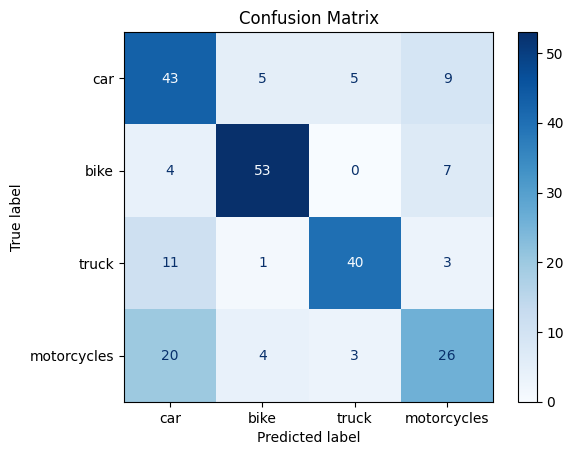

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Accuracy
print(f"Accuracy final: {resultados_test['accuracy']:.4f}")

# Confusion matrix (raw)
print("\n \nMatriz de confusión:")
#gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=resultados_test['confusion_matrix'],
    display_labels=classes
)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(resultados_test)

{'predictions': array(['car', 'car', 'car', 'truck', 'truck', 'car', 'car', 'car', 'car',
       'motorcycles', 'car', 'car', 'car', 'car', 'bike', 'car', 'car',
       'bike', 'car', 'motorcycles', 'motorcycles', 'car', 'motorcycles',
       'truck', 'car', 'car', 'car', 'motorcycles', 'bike', 'car', 'car',
       'motorcycles', 'bike', 'bike', 'car', 'car', 'car', 'car',
       'motorcycles', 'motorcycles', 'car', 'motorcycles', 'car', 'car',
       'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car',
       'car', 'car', 'truck', 'car', 'car', 'truck', 'car', 'car', 'car',
       'bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'bike',
       'bike', 'motorcycles', 'bike', 'motorcycles', 'bike', 'bike',
       'bike', 'bike', 'bike', 'motorcycles', 'bike', 'bike', 'bike',
       'motorcycles', 'bike', 'bike', 'bike', 'bike', 'bike', 'car',
       'bike', 'bike', 'bike', 'bike', 'bike', 'motorcycles',
       'motorcycles', 'bike', 'bike', 'bike', 'bike', 'bike', 'bik

In [ ]:
import pickle
import time

# Guardamos los resultados
with open("resultados-sift-minikmeans-extradata-2000", "wb") as f:
    pickle.dump(resultados_test, f)

In [ ]:
import pickle
import time


#Cargamos los resultados

with open("auxiliar2.pkl", "rb") as f:
    resultados_tupla = pickle.load(f)

ModuleNotFoundError: No module named 'numpy._core'

In [ ]:
print(resultados_tupla)

([{'n_keypoints': 100, 'n_visual_words': 20, 'accuracy_promedio': 0.5030608974358974, 'f1_promedio': 0.4916529930350671, 'total_time': 65.4986400604248, 'avg_time': 0.06752437119631423}, {'n_keypoints': 100, 'n_visual_words': 50, 'accuracy_promedio': 0.5484134615384616, 'f1_promedio': 0.5453256800742312, 'total_time': 127.8700544834137, 'avg_time': 0.13182479843650896}, {'n_keypoints': 100, 'n_visual_words': 100, 'accuracy_promedio': 0.500625, 'f1_promedio': 0.49068835868629135, 'total_time': 125.76309275627136, 'avg_time': 0.12965267294460966}, {'n_keypoints': 100, 'n_visual_words': 200, 'accuracy_promedio': 0.524551282051282, 'f1_promedio': 0.5180518247152776, 'total_time': 217.11724090576172, 'avg_time': 0.22383220711934199}, {'n_keypoints': 100, 'n_visual_words': 300, 'accuracy_promedio': 0.5382211538461538, 'f1_promedio': 0.5319403993641975, 'total_time': 365.1863923072815, 'avg_time': 0.3764808168116304}, {'n_keypoints': 250, 'n_visual_words': 20, 'accuracy_promedio': 0.532179487

In [ ]:
resultados = resultados_tupla[0]
resultados_test = resultados_tupla[1]